# Week 2 - Preprocessing, part 2

# 1. Lesson: None

# 2. Weekly graph question

The Storytelling With Data book mentions planning on a "Who, What, and How" for your data story.  Write down a possible Who, What, and How for your data, using the ideas in the book.

**Who -** This data could be helpful to NBA Sports bettors, betting markets, NBA teams and analysts and quantitative traders applying models to betting markets.
**What -** This data provides us with NBA game outcomes and sports betting markets using historical NBA game data, betting lines, and player box scores. In other words, it covers 3 sectors betting market data, team-level game data, and player-level statistics. Questions we can answer with this data: Can we predict who wins an NBA game? Which team/player metrics most influence outcomes? Does  the betting market accurately price games?
**How** We can combine the datasets at the game level using a shared game identifier. Then we can possibly build classification models to predict win/loss. Or we can build regression models to predict margin of victory or total points scored. Or we can also analyze feature importance to determine which team or player metrics drive outcomes.

# 3. Homework - work with your own data

In [1]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import kagglehub
import os
import matplotlib.pyplot as plt

/Users/josuelegarda/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/josuelegarda/Library/Python/3.9/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Download latest version
path_nba_stats = kagglehub.dataset_download("eoinamoore/historical-nba-data-and-player-box-scores")

print("Path to dataset files:", path_nba_stats)

path_betting_stats = kagglehub.dataset_download("cviaxmiwnptr/nba-betting-data-october-2007-to-june-2024")

print("Path to dataset files:", path_betting_stats)

100%|██████████| 1.03G/1.03G [03:29<00:00, 5.30MB/s]

Extracting files...


Path to dataset files: /Users/josuelegarda/.cache/kagglehub/datasets/eoinamoore/historical-nba-data-and-player-box-scores/versions/511
Path to dataset files: /Users/josuelegarda/.cache/kagglehub/datasets/cviaxmiwnptr/nba-betting-data-october-2007-to-june-2024/versions/2


In [3]:
print("NBA stats files:")
print(os.listdir(path_nba_stats))

print("\nBetting stats files:")
print(os.listdir(path_betting_stats))


NBA stats files:
['LeagueSchedule25_26.csv', 'TeamStatisticsExtended.csv', 'PlayByPlay.parquet', 'PlayerStatisticsExtended.csv', 'TeamStatistics.csv', 'LeagueSchedule24_25.csv', 'PlayerStatistics.csv', 'Players.csv', 'TeamHistories.csv', 'Games.csv']

Betting stats files:
['nba_2008-2025.csv']


In [4]:
games = pd.read_csv(os.path.join(path_nba_stats,"Games.csv"))
player_stats = pd.read_csv(os.path.join(path_nba_stats,"PlayerStatistics.csv"))
team_histories = pd.read_csv(os.path.join(path_nba_stats,"TeamHistories.csv"))
betting_stats = pd.read_csv(os.path.join(path_betting_stats,"nba_2008-2025.csv"))

games_cleaned = games.copy()
player_stats_cleaned = player_stats.copy()
team_histories_cleaned = team_histories.copy()
betting_stats_cleaned = betting_stats.copy()

/var/folders/fj/fkly19253s58fj8xwtwph5cw0000gn/T/ipykernel_52150/3154669079.py:1: DtypeWarning: Columns (12,14,15,18,19,20,21) have mixed types. Specify dtype option on import or set low_memory=False.
  games = pd.read_csv(os.path.join(path_nba_stats,"Games.csv"))
/var/folders/fj/fkly19253s58fj8xwtwph5cw0000gn/T/ipykernel_52150/3154669079.py:2: DtypeWarning: Columns (10,11,12,15,37,38) have mixed types. Specify dtype option on import or set low_memory=False.
  player_stats = pd.read_csv(os.path.join(path_nba_stats,"PlayerStatistics.csv"))


## Data Cleaning / Quality Checks

In [5]:
games_cleaned.describe()

,gameId,hometeamId,awayteamId,homeScore,awayScore,winner,attendance,arenaId
count,7.327800e+04,7.327800e+04,7.327800e+04,73278.000000,73278.000000,7.327800e+04,1391.000000,7.327800e+04
mean,2.578516e+07,1.610613e+09,1.610481e+09,106.035536,102.492058,1.610613e+09,18020.778577,4.354953e+04
std,6.418175e+06,4.109048e+01,1.457330e+07,14.316530,13.974101,4.108591e+01,1756.102086,2.038975e+05
min,1.030000e+07,1.610613e+09,1.501600e+04,0.000000,0.000000,1.610613e+09,5993.000000,0.000000e+00
25%,2.130086e+07,1.610613e+09,1.610613e+09,96.000000,93.000000,1.610613e+09,17071.000000,5.000000e+00
50%,2.610034e+07,1.610613e+09,1.610613e+09,106.000000,102.000000,1.610613e+09,18186.000000,4.400000e+01
75%,2.870034e+07,1.610613e+09,1.610613e+09,116.000000,112.000000,1.610613e+09,19403.000000,1.360000e+02
max,6.250000e+07,1.610617e+09,1.610617e+09,184.000000,186.000000,1.610617e+09,22093.000000,1.000159e+06


In [6]:
player_stats_cleaned.describe()

,personId,gameId,win,home,points,assists,blocks,steals,fieldGoalsAttempted,fieldGoalsMade,...,freeThrowsMade,freeThrowsPercentage,reboundsDefensive,reboundsOffensive,reboundsTotal,foulsPersonal,turnovers,plusMinusPoints,playerteamId,opponentteamId
count,1.669847e+06,1.669892e+06,1.666369e+06,1.666379e+06,1.668205e+06,1.668205e+06,1.668205e+06,1.668205e+06,1.668205e+06,1.668205e+06,...,1.668205e+06,1.668205e+06,1.668205e+06,1.668205e+06,1.668205e+06,1.668205e+06,1.668205e+06,1.667257e+06,1.560593e+06,1.560593e+06
mean,7.350437e+05,2.534856e+07,4.997729e-01,5.005536e-01,9.182981e+00,1.960700e+00,3.683966e-01,5.843107e-01,7.307055e+00,3.484693e+00,...,1.774574e+00,4.210620e-01,2.179360e+00,8.524078e-01,3.766555e+00,1.966812e+00,1.034719e+00,-5.997876e-05,1.610613e+09,1.610613e+09
std,2.851783e+07,6.537601e+06,5.000001e-01,4.999998e-01,8.528675e+00,2.544613e+00,8.312785e-01,9.604140e-01,6.358366e+00,3.308435e+00,...,2.447539e+00,4.255219e-01,2.676820e+00,1.386409e+00,3.928614e+00,1.657026e+00,1.404713e+00,7.490378e+00,1.263802e+02,1.263804e+02
min,2.000000e+00,1.030000e+07,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-6.200000e+01,1.610613e+09,1.610613e+09
25%,1.762000e+03,2.120044e+07,0.000000e+00,0.000000e+00,2.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.000000e+00,1.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.610613e+09,1.610613e+09
50%,7.714900e+04,2.250102e+07,0.000000e+00,1.000000e+00,7.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,6.000000e+00,3.000000e+00,...,1.000000e+00,5.000000e-01,1.000000e+00,0.000000e+00,3.000000e+00,2.000000e+00,0.000000e+00,0.000000e+00,1.610613e+09,1.610613e+09
75%,2.019540e+05,2.860040e+07,1.000000e+00,1.000000e+00,1.400000e+01,3.000000e+00,0.000000e+00,1.000000e+00,1.100000e+01,5.000000e+00,...,3.000000e+00,8.560000e-01,3.000000e+00,1.000000e+00,6.000000e+00,3.000000e+00,2.000000e+00,0.000000e+00,1.610613e+09,1.610613e+09
max,1.966938e+09,6.250000e+07,1.000000e+00,1.000000e+00,1.060000e+02,3.000000e+01,1.700000e+01,1.900000e+01,8.800000e+01,3.800000e+01,...,3.600000e+01,1.100000e+01,4.200000e+01,2.100000e+01,5.700000e+01,3.300000e+01,3.400000e+01,5.700000e+01,1.610617e+09,1.610617e+09


In [7]:
team_histories_cleaned.describe()


,teamId,seasonFounded,seasonActiveTill
count,1.400000e+02,140.000000,140.000000
mean,7.823023e+08,1970.192857,2037.414286
std,8.078635e+08,26.628782,65.796392
min,9.001000e+03,1913.000000,1948.000000
25%,9.032750e+03,1948.750000,1965.750000
50%,9.065500e+03,1968.000000,2061.500000
75%,1.610613e+09,1995.000000,2100.000000
max,1.610613e+09,2021.000000,2100.000000


In [8]:
betting_stats_cleaned.describe()

,season,score_away,score_home,q1_away,q2_away,q3_away,q4_away,ot_away,q1_home,q2_home,...,q4_home,ot_home,spread,total,moneyline_away,moneyline_home,h2_spread,h2_total,id_spread,id_total
count,23118.000000,23118.000000,23118.000000,23118.000000,23118.000000,23118.000000,23118.000000,23118.000000,23118.000000,23118.000000,...,23118.000000,23118.000000,23115.000000,23118.000000,19820.000000,19820.000000,19822.000000,19817.000000,23115.000000,23118.000000
mean,2016.500389,103.933731,106.579894,26.009776,26.097327,25.743144,25.412233,0.671252,26.897353,26.760057,...,25.781166,0.710356,6.150422,210.181395,124.229263,-254.547780,3.576716,103.027330,0.521999,0.515789
std,5.212645,13.710616,13.567418,5.951920,5.901064,6.037957,5.984585,3.047784,5.975630,5.910055,...,5.891295,3.190743,3.683346,15.450553,430.106555,680.035795,2.579336,7.077542,0.527744,0.522527
min,2008.000000,54.000000,59.000000,7.000000,4.000000,5.000000,5.000000,0.000000,5.000000,5.000000,...,7.000000,0.000000,0.000000,170.000000,-9900.000000,-13000.000000,0.000000,84.000000,0.000000,0.000000
25%,2012.000000,94.000000,97.000000,22.000000,22.000000,22.000000,21.000000,0.000000,23.000000,23.000000,...,22.000000,0.000000,3.500000,197.500000,-140.000000,-340.000000,1.500000,97.500000,0.000000,0.000000
50%,2016.000000,104.000000,106.000000,26.000000,26.000000,26.000000,25.000000,0.000000,27.000000,27.000000,...,26.000000,0.000000,5.500000,210.000000,145.000000,-170.000000,3.000000,103.000000,1.000000,1.000000
75%,2021.000000,113.000000,116.000000,30.000000,30.000000,30.000000,29.000000,0.000000,31.000000,31.000000,...,30.000000,0.000000,8.500000,222.000000,280.000000,120.000000,5.000000,108.000000,1.000000,1.000000
max,2025.000000,176.000000,175.000000,55.000000,49.000000,52.000000,51.000000,44.000000,55.000000,51.000000,...,50.000000,41.000000,23.500000,262.500000,6500.000000,3000.000000,16.500000,125.000000,2.000000,2.000000


In [9]:
games_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73278 entries, 0 to 73277
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gameId            73278 non-null  int64  
 1   gameDateTimeEst   73278 non-null  object 
 2   hometeamCity      73271 non-null  object 
 3   hometeamName      73278 non-null  object 
 4   hometeamId        73278 non-null  int64  
 5   awayteamCity      73271 non-null  object 
 6   awayteamName      73278 non-null  object 
 7   awayteamId        73278 non-null  int64  
 8   homeScore         73278 non-null  int64  
 9   awayScore         73278 non-null  int64  
 10  winner            73278 non-null  int64  
 11  gameType          73278 non-null  object 
 12  gameSubtype       74 non-null     object 
 13  gameLabel         4042 non-null   object 
 14  gameSubLabel      327 non-null    object 
 15  seriesGameNumber  5822 non-null   object 
 16  attendance        1391 non-null   float6

In [10]:
player_stats_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1669892 entries, 0 to 1669891
Data columns (total 40 columns):
 #   Column                   Non-Null Count    Dtype  
---  ------                   --------------    -----  
 0   firstName                1669658 non-null  object 
 1   lastName                 1669654 non-null  object 
 2   personId                 1669847 non-null  float64
 3   gameId                   1669892 non-null  int64  
 4   gameDateTimeEst          1666379 non-null  object 
 5   playerteamCity           1669724 non-null  object 
 6   playerteamName           1666379 non-null  object 
 7   opponentteamCity         1666211 non-null  object 
 8   opponentteamName         1666379 non-null  object 
 9   gameType                 1669842 non-null  object 
 10  gameLabel                117418 non-null   object 
 11  gameSubLabel             105061 non-null   object 
 12  seriesGameNumber         137427 non-null   object 
 13  win                      1666369 non-null 

In [11]:
team_histories_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 140 entries, 0 to 139
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   teamId            140 non-null    int64 
 1   teamCity          140 non-null    object
 2   teamName          140 non-null    object
 3   teamAbbrev        140 non-null    object
 4   seasonFounded     140 non-null    int64 
 5   seasonActiveTill  140 non-null    int64 
 6   league            140 non-null    object
dtypes: int64(3), object(4)
memory usage: 7.8+ KB


In [ ]:
betting_stats_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23118 entries, 0 to 23117
Data columns (total 27 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   season          23118 non-null  int64  
 1   date            23118 non-null  object 
 2   regular         23118 non-null  bool   
 3   playoffs        23118 non-null  bool   
 4   away            23118 non-null  object 
 5   home            23118 non-null  object 
 6   score_away      23118 non-null  int64  
 7   score_home      23118 non-null  int64  
 8   q1_away         23118 non-null  int64  
 9   q2_away         23118 non-null  int64  
 10  q3_away         23118 non-null  int64  
 11  q4_away         23118 non-null  int64  
 12  ot_away         23118 non-null  int64  
 13  q1_home         23118 non-null  int64  
 14  q2_home         23118 non-null  int64  
 15  q3_home         23118 non-null  int64  
 16  q4_home         23118 non-null  int64  
 17  ot_home         23118 non-null 

In [ ]:
# Change data types (games)
games_cleaned['gameId'] = games_cleaned['gameId'].astype(str)
games_cleaned['gameDateTimeEst'] = pd.to_datetime(games_cleaned['gameDateTimeEst'])
games_cleaned['hometeamId'] = games_cleaned['hometeamId'].astype(str)
games_cleaned['awayteamId'] = games_cleaned['awayteamId'].astype(str)
games_cleaned['winner'] = games_cleaned['winner'].astype(str)
games_cleaned['arenaId'] = games_cleaned['arenaId'].astype(str)
games_cleaned['gameDate'] = pd.to_datetime(games_cleaned['gameDate'])

# Change data types (player_stats)
player_stats_cleaned['gameDate'] = pd.to_datetime(player_stats_cleaned['gameDate'])
player_stats_cleaned['personId'] = player_stats_cleaned['personId'].astype(str)
player_stats_cleaned['gameId'] = player_stats_cleaned['gameId'].astype(str)
player_stats_cleaned['playerteamId'] = player_stats_cleaned['playerteamId'].astype(str)
player_stats_cleaned = player_stats_cleaned[
    player_stats_cleaned['fieldGoalsMade'] <=
    player_stats_cleaned['fieldGoalsAttempted']
]

def clean_minutes(x):
    # Missing values
    if pd.isna(x):
        return np.nan
    # MM:SS format
    if isinstance(x, str) and ':' in x:
        mins, secs = x.split(':')
        return int(mins) + int(secs) / 60
    # Everything else (floats and strings like "27")
    return float(x)
player_stats_cleaned['numMinutes'] = (
    player_stats_cleaned['numMinutes']
    .apply(clean_minutes)
)

# Change data types (team_histories)
team_histories_cleaned['teamId'] = team_histories_cleaned['teamId'].astype(str)
team_histories_cleaned['seasonFounded'] = pd.to_datetime(team_histories_cleaned['seasonFounded'])
team_histories_cleaned['seasonActiveTill'] = pd.to_datetime(team_histories_cleaned['seasonActiveTill'])
team_histories_cleaned = team_histories_cleaned[team_histories_cleaned['league'] == 'NBA']
team_histories_cleaned['seasonFounded_year'] = (
    team_histories_cleaned['seasonFounded']
    .astype(str)
    .str.extract(r'(\d{4})$')[0]
    .astype(int)
)
team_histories_cleaned['seasonActiveTill_year'] = (
    team_histories_cleaned['seasonActiveTill']
    .astype(str)
    .str.extract(r'(\d{4})$')[0]
    .astype(int)
)
team_histories_cleaned.loc[team_histories_cleaned['seasonActiveTill_year'] == 2100, 'seasonActiveTill_year'] = pd.Timestamp.now()
team_histories_cleaned = team_histories_cleaned.drop(columns=['seasonActiveTill', 'seasonFounded'])
team_histories_cleaned['seasonFounded_year'] = pd.to_datetime(team_histories_cleaned['seasonFounded_year'])
team_histories_cleaned['seasonActiveTill_year'] = pd.to_datetime(team_histories_cleaned['seasonActiveTill_year'])

# (betting_stats)
betting_stats_cleaned['favoriteTeam'] = np.select(
    [
        betting_stats_cleaned['whos_favored'] == 'home',
        betting_stats_cleaned['whos_favored'] == 'away'
    ],
    [
        betting_stats_cleaned['home'],
        betting_stats_cleaned['away']
    ],
    default='N/A'
)

'No changes needed'

In [13]:
# Check for duplicates
print(f'gamed df duplicates: {games_cleaned.duplicated().sum()}')
print(f'player_stats df duplicates: {player_stats_cleaned.duplicated().sum()}') 
print(f'team_histories df duplicates: {team_histories_cleaned.duplicated().sum()}')
print(f'betting_stats df duplicates: {betting_stats_cleaned.duplicated().sum()}')

"""No duplicates"""

gamed df duplicates: 0
player_stats df duplicates: 0
team_histories df duplicates: 0
betting_stats df duplicates: 0


'No duplicates'

In [14]:
# Quick Stats (games)
print(f'The mean for games df homeScore is: {games_cleaned["homeScore"].mean()}')
print(f'The median for games df homeScore is: {games_cleaned["homeScore"].median()}')
print(f'The mode for games df homeScore is: {games_cleaned["homeScore"].mode()}')

print('---------------------------------------------------------------------')

print(f'The mode for games df awayScore is: {games_cleaned["awayScore"].mode()}')
print(f'The median for games df awayScore is: {games_cleaned["awayScore"].median()}')
print(f'The mode for games df awayScore is: {games_cleaned["awayScore"].mode()}')

print('---------------------------------------------------------------------')

print(f'The mode for games df attendance is: {games_cleaned["attendance"].mode()}')
print(f'The median for games df attendance is: {games_cleaned["attendance"].median()}')
print(f'The mode for games df attendance is: {games_cleaned["attendance"].mode()}')

print('---------------------------------------------------------------------')

# Quick Stats (player_stats)
print(f'The mean for player_stats df points is: {player_stats_cleaned["points"].mean()}')
print(f'The median for player_stats df points is: {player_stats_cleaned["points"].median()}')
print(f'The mode for player_stats df points is: {player_stats_cleaned["points"].mode()}')

print('---------------------------------------------------------------------')

# Quick Stats (betting_stats)
print(f'The mean for betting_stats df points is: {betting_stats_cleaned["score_home"].mean()}')
print(f'The median for betting_stats df points is: {betting_stats_cleaned["score_home"].median()}')
print(f'The mode for betting_stats df points is: {betting_stats_cleaned["score_home"].mode()}')


"""We checked only columns that are ints and are important. Seems like we will need to run some cleaning on nulls"""


The mean for games df homeScore is: 106.0355359043642
The median for games df homeScore is: 106.0
The mode for games df homeScore is: 0    104
Name: homeScore, dtype: int64
---------------------------------------------------------------------
The mode for games df awayScore is: 0    103
Name: awayScore, dtype: int64
The median for games df awayScore is: 102.0
The mode for games df awayScore is: 0    103
Name: awayScore, dtype: int64
---------------------------------------------------------------------
The mode for games df attendance is: 0    19432.0
Name: attendance, dtype: float64
The median for games df attendance is: 18186.0
The mode for games df attendance is: 0    19432.0
Name: attendance, dtype: float64
---------------------------------------------------------------------
The mean for player_stats df points is: 9.182981108436913
The median for player_stats df points is: 7.0
The mode for player_stats df points is: 0    0.0
Name: points, dtype: float64
----------------------------

'We checked only columns that are ints and are important. Seems like we will need to run some cleaning on nulls'

In [15]:
# Handling Nulls (games)

games_imp_cols = games_cleaned[['gameDate', 'awayScore', 'homeScore', 'hometeamName' , 'hometeamId', 'awayteamName' , 'awayteamId','gameDateTimeEst' ]]

rows_to_drop = []


mask_drop = (
    (games_imp_cols['gameDate'].isna() & games_imp_cols['gameDateTimeEst'].isna()) |
    (games_imp_cols['awayScore'].isna() & games_imp_cols['homeScore'].isna()) |
    (games_imp_cols['homeScore'].isna() & games_imp_cols['hometeamId'].isna()) |
    (games_imp_cols['awayScore'].isna() & games_imp_cols['awayteamId'].isna())
)

rows_to_drop = games_imp_cols[mask_drop].index.tolist()
print(f'Need to drop these row #s: {rows_to_drop}')

"""The logic behind this was to check if we have any significant nulls in our dataset. By significant I refer to critical data we need to feed any model."""
"""For example, I narrowed down the dataset to include only columns that would be relevant to feed a model. Then from this new df, I tested out logic to find any significant nulls."""
"""For example, in the case of gameDate vs gameDateTimeEst, I think we will need the date of the game for sure. There could be a scenario which only one of these is null so I would not like to drop that column and use the one that is not null"""
"""Overall, we may have nulls in this new df but would not be significant for now"""

Need to drop these row #s: []


'Overall, we may have nulls in this new df but would not be significant for now'

In [16]:
# Handling Nulls (player_stats)

player_stats_imp_cols = player_stats_cleaned[['gameDateTimeEst', 'gameDate', 'personId', 'gameId', 'points' ]]

rows_to_drop = []


mask_drop = (
    (player_stats_cleaned['gameDate'].isna() & player_stats_imp_cols['gameDateTimeEst'].isna()) |
    (player_stats_cleaned['personId'].isna()) |
    (player_stats_cleaned['gameId'].isna()) |
    (player_stats_cleaned['points'].isna())
)

rows_to_drop = player_stats_imp_cols[mask_drop].index.tolist()      
print(f'Need to drop these row #s: {rows_to_drop}')

player_stats = player_stats_cleaned.drop(rows_to_drop, axis=0)

"""The logic behind this was to check if we have any significant nulls in our dataset. By significant I refer to critical data we need to feed any model."""
"""For example, I narrowed down the dataset to include only columns that would be relevant to feed a model. Then from this new df, I tested out logic to find any significant nulls."""
"""For example, in the case of gameDate vs gameDateTimeEst, I think we will need the date of the game for sure. There could be a scenario which only one of these is null so I would not like to drop that column and use the one that is not null"""
"""Overall, we may have nulls in this new df but would not be significant for now"""

Need to drop these row #s: [285196, 285197, 285198, 285199, 285200, 285201, 285202, 285203, 285204, 285205, 285206, 285207, 285208, 285209, 285210, 285211, 285212, 285213, 285214, 285215, 285216, 285217, 285218, 285219, 285220, 285221, 285222, 285223, 285224, 285225, 285226, 285227, 285228, 285229, 285230, 285231, 285232, 285233, 285234, 285235, 285236, 285237, 285238, 285239, 285240, 285241, 285242, 285243, 285244, 285245, 285246, 285247, 285248, 285249, 285250, 285251, 285252, 285253, 285254, 285255, 285256, 285257, 285258, 285259, 285260, 285261, 285262, 285263, 285264, 285265, 285266, 285267, 285268, 285269, 285270, 285271, 285272, 285273, 285274, 285275, 285276, 285277, 285278, 285279, 285280, 285281, 285282, 285283, 285284, 285285, 285286, 285287, 285288, 285289, 285290, 285291, 285292, 285293, 285294, 285295, 285296, 285297, 285298, 285299, 285300, 285301, 285302, 285303, 285304, 285305, 285306, 285307, 285308, 285309, 285310, 285311, 285312, 285313, 285314, 285315, 285316, 2853

'Overall, we may have nulls in this new df but would not be significant for now'

In [17]:
# Handling Nulls (team_histories)

team_histories_imp_cols = team_histories_cleaned[['teamId', 'teamCity', 'teamName']]

rows_to_drop = []


mask_drop = (
    (team_histories_cleaned['teamId'].isna()) |
    (team_histories_cleaned['teamCity'].isna() & team_histories_cleaned['teamName'].isna())
)

rows_to_drop = team_histories_imp_cols[mask_drop].index.tolist()
print(f'Need to drop these row #s: {rows_to_drop}')


"""The logic behind this was to check if we have any significant nulls in our dataset. By significant I refer to critical data we need to feed any model."""
"""For example, I narrowed down the dataset to include only columns that would be relevant to feed a model. Then from this new df, I tested out logic to find any significant nulls."""
"""For example, in the case of gameDate vs gameDateTimeEst, I think we will need the date of the game for sure. There could be a scenario which only one of these is null so I would not like to drop that column and use the one that is not null"""
"""Overall, we may have nulls in this new df but would not be significant for now"""

Need to drop these row #s: []


'Overall, we may have nulls in this new df but would not be significant for now'

In [18]:
# Handling Nulls (betting_stats)

betting_stats_imp_cols = betting_stats_cleaned[['date', 'whos_favored', 'spread','moneyline_away', 'moneyline_home']]

rows_to_drop = []


mask_drop = (
    (betting_stats_cleaned['date'].isna()) |
    (betting_stats_cleaned['whos_favored'].isna()) |
    (betting_stats_cleaned['spread'].isna()) |
    (betting_stats_cleaned['moneyline_away'].isna()) |
    (betting_stats_cleaned['moneyline_home'].isna()) 

)

rows_to_drop = betting_stats_imp_cols[mask_drop].index.tolist()
print(f'Need to drop these row #s: {rows_to_drop}')

betting_stats = betting_stats_cleaned.drop(rows_to_drop, axis=0)

"""The logic behind this was to check if we have any significant nulls in our dataset. By significant I refer to critical data we need to feed any model."""
"""For example, I narrowed down the dataset to include only columns that would be relevant to feed a model. Then from this new df, I tested out logic to find any significant nulls."""
"""For example, in the case of gameDate vs gameDateTimeEst, I think we will need the date of the game for sure. There could be a scenario which only one of these is null so I would not like to drop that column and use the one that is not null"""
"""Overall, we may have nulls in this new df but would not be significant for now"""

Need to drop these row #s: [1092, 2702, 15939, 18724, 18747, 19822, 19823, 19824, 19825, 19826, 19827, 19828, 19829, 19830, 19831, 19832, 19833, 19834, 19835, 19836, 19837, 19838, 19839, 19840, 19841, 19842, 19843, 19844, 19845, 19846, 19847, 19848, 19849, 19850, 19851, 19852, 19853, 19854, 19855, 19856, 19857, 19858, 19859, 19860, 19861, 19862, 19863, 19864, 19865, 19866, 19867, 19868, 19869, 19870, 19871, 19872, 19873, 19874, 19875, 19876, 19877, 19878, 19879, 19880, 19881, 19882, 19883, 19884, 19885, 19886, 19887, 19888, 19889, 19890, 19891, 19892, 19893, 19894, 19895, 19896, 19897, 19898, 19899, 19900, 19901, 19902, 19903, 19904, 19905, 19906, 19907, 19908, 19909, 19910, 19911, 19912, 19913, 19914, 19915, 19916, 19917, 19918, 19919, 19920, 19921, 19922, 19923, 19924, 19925, 19926, 19927, 19928, 19929, 19930, 19931, 19932, 19933, 19934, 19935, 19936, 19937, 19938, 19939, 19940, 19941, 19942, 19943, 19944, 19945, 19946, 19947, 19948, 19949, 19950, 19951, 19952, 19953, 19954, 19955, 1

'Overall, we may have nulls in this new df but would not be significant for now'

In [19]:
# Check for inconsistent data (games)
print(f'hometeamNames: {games_cleaned["hometeamName"].unique()}')
print(f'awayteamName: {games_cleaned["awayteamName"].unique()}')
print(f'arenaCity: {games_cleaned["arenaCity"].unique()}')

"""Data seems to be consistent throughout. No need for additional cleaning for now. I do notice that some data is outdated but will be fixed when we filter out old teams"""
"""Also no need for one hot encoding seems all fields seem to be self explanatory and dont need encoding"""

hometeamNames: ['Knicks' 'Spurs' 'Thunder' 'Cavaliers' 'Pistons' 'Timberwolves' 'Lakers'
 '76ers' 'Celtics' 'Rockets' 'Raptors' 'Magic' 'Hawks' 'Nuggets' 'Suns'
 'Trail Blazers' 'Clippers' 'Hornets' 'Mavericks' 'Pacers' 'Heat' 'Kings'
 'Jazz' 'Bulls' 'Bucks' 'Wizards' 'Warriors' 'Nets' 'Pelicans' 'Grizzlies'
 'Stripes' 'Stars' 'Team Melo' 'Team T-Mac' 'Bobcats' 'SuperSonics'
 'Bullets' 'Braves' 'Royals' 'Nationals' 'Zephyrs' 'Packers' 'Blackhawks']
awayteamName: ['Spurs' 'Knicks' 'Thunder' 'Cavaliers' 'Pistons' 'Timberwolves' 'Lakers'
 '76ers' 'Raptors' 'Magic' 'Nuggets' 'Celtics' 'Rockets' 'Trail Blazers'
 'Hawks' 'Suns' 'Warriors' 'Hornets' 'Heat' 'Bulls' 'Grizzlies' 'Pelicans'
 'Jazz' 'Kings' 'Wizards' 'Bucks' 'Nets' 'Clippers' 'Mavericks' 'Pacers'
 'Stars' 'World' 'Team Vince' 'Team Austin' 'Loong-Lions' 'Phoenix'
 'Jerusalem B.C.' 'United' 'Bobcats' 'SuperSonics' 'Bullets' 'Braves'
 'Royals' 'Nationals' 'Zephyrs' 'Packers' 'Blackhawks']
arenaCity: ['New York' 'San Antonio' 'Oklaho

'Also no need for one hot encoding seems all fields seem to be self explanatory and dont need encoding'

In [20]:
# Check for inconsistent data (player_stats)
print(f'personId: {player_stats_cleaned["personId"].unique()}')
print(f'gameId: {player_stats_cleaned["gameId"].unique()}')
print(f'points: {player_stats_cleaned["points"].unique()}')

"""Data seems to be consistent throughout. No need for additional cleaning for now. I do notice that some data is outdated but will be fixed when we filter out old teams"""
"""Also no need for one hot encoding seems all fields seem to be self explanatory and dont need encoding"""

personId: ['1628384.0' '1629013.0' '202687.0' ... '196295093.0' '196295099.0'
 '196295090.0']
gameId: ['42500404' '42500403' '42500402' ... '12400011' '12400029' '12400060']
points: [ 33.   0.  18.   7.   5.  13.  24.   2.   6.  21.   8.  36.  23.   4.
   3.  11.  28.  10.  32.  16.  12.   1.  20.  29.  14.  17.  15.   9.
  30.  26.  35.  22.  19.  31.  25.  38.  41.  39.  27.  43.  34.  45.
  42.  37.  40.  51.  47.  53.  60.  83.  44.  49.  46.  55.  50.  56.
  48.  52.  54.  61.  59.  73.  62.  70.  64.  57.  71.  58.  nan  65.
  81.  69.  63.  68.  66.  67.  72. 100.  78.  87. 102. 104.  82. 106.
  80.  77.  89.  94.  92.  86.  85.  84.  75.  99.]


'Also no need for one hot encoding seems all fields seem to be self explanatory and dont need encoding'

In [21]:
# Check for inconsistent data (team_histories)
print(f'teamCity: {team_histories_cleaned["teamCity"].unique()}')
print(f'teamName: {team_histories_cleaned["teamName"].unique()}')

"""Data seems to be consistent throughout. No need for additional cleaning for now. I do notice that some data is outdated but will be fixed when we filter out old teams"""
"""Also no need for one hot encoding seems all fields seem to be self explanatory and dont need encoding"""

teamCity: ['Tri-Cities' 'Milwaukee' 'St. Louis' 'Atlanta' 'Boston' 'Cleveland'
 'New Orleans' 'Oklahoma City' 'Chicago' 'Dallas' 'Denver' 'Philadelphia'
 'San Francisco' 'Golden State' 'San Diego' 'Houston' 'Buffalo'
 'Los Angeles' 'Minneapolis' 'Miami' 'Minnesota' 'New York' 'New Jersey'
 'Brooklyn' 'Orlando' 'Indiana' 'Syracuse' 'Phoenix' 'Portland'
 'Rochester' 'Cincinnati' 'Kansas City-Omaha' 'Kansas City' 'Sacramento'
 'San Antonio' 'Seattle' 'Toronto' 'Utah' 'Vancouver' 'Memphis'
 'Baltimore' 'Capital' 'Washington' 'Ft. Wayne Zollner' 'Detroit'
 'Charlotte' 'Pittsburgh' 'Siena' 'Rome' 'Beijing' 'Athens' 'Istanbul'
 'All-Star' 'Sheboygan' 'Shanghai' 'Anderson' 'Adelaide' 'Auckland' 'East'
 'Cairns' 'Barcelona' 'Bilbao' 'Madrid' 'Buenos Aires' 'Haifa' 'Milan'
 'Moscow' 'West' 'Waterloo' 'Belgrade' 'Indianapolis' 'Khimki'
 'Franca (Brazil)' 'Brisbane' 'Vilnius' 'Vitoria-Gasteiz'
 'Lyon-Villeurbanne' 'Perth' 'Sydney' 'China' 'Malaga' 'Berlin'
 'Guangzhou' 'Melbourne' 'Tel Aviv' 'Prov

'Also no need for one hot encoding seems all fields seem to be self explanatory and dont need encoding'

In [22]:
# Check for inconsistent data (betting_stats)
print(f'whose_favored: {betting_stats_cleaned["whos_favored"].unique()}')

"""Data seems to be consistent throughout. No need for additional cleaning for now. I do notice that some data is outdated but will be fixed when we filter out old teams"""
"""Also no need for one hot encoding seems all fields seem to be self explanatory and dont need encoding"""


whose_favored: ['home' 'away']


'Also no need for one hot encoding seems all fields seem to be self explanatory and dont need encoding'

In [23]:
games_cleaned.head()

,gameId,gameDateTimeEst,hometeamCity,hometeamName,hometeamId,awayteamCity,awayteamName,awayteamId,homeScore,awayScore,...,gameLabel,gameSubLabel,seriesGameNumber,attendance,arenaId,arenaName,arenaCity,arenaState,officials,gameDate
0,42500404,2026-06-10 20:30:00,New York,Knicks,1610612752,San Antonio,Spurs,1610612759,107,106,...,NBA Finals,Game 4,Game 4,19812.0,30,Madison Square Garden,New York,NY,"Courtney Kirkland, Zach Zarba, James Williams,...",2026-06-10 20:30:00
1,42500403,2026-06-08 20:30:00,New York,Knicks,1610612752,San Antonio,Spurs,1610612759,111,115,...,NBA Finals,Game 3,Game 3,19812.0,30,Madison Square Garden,New York,NY,"Marc Davis, John Goble, Curtis Blair, Nick Buc...",2026-06-08 20:30:00
2,42500402,2026-06-05 20:30:00,San Antonio,Spurs,1610612759,New York,Knicks,1610612752,104,105,...,NBA Finals,Game 2,Game 2,19014.0,1000118,Frost Bank Center,San Antonio,TX,"Tony Brothers, Josh Tiven, Mitchell Ervin, Tyl...",2026-06-05 20:30:00
3,42500401,2026-06-03 20:30:00,San Antonio,Spurs,1610612759,New York,Knicks,1610612752,95,105,...,NBA Finals,Game 1,Game 1,18835.0,1000118,Frost Bank Center,San Antonio,TX,"James Capers, JB DeRosa, Scott Foster, Sean Wr...",2026-06-03 20:30:00
4,42500317,2026-05-30 20:00:00,Oklahoma City,Thunder,1610612760,San Antonio,Spurs,1610612759,103,111,...,West Conf. Finals,Game 7,Game 7,18203.0,1000052,Paycom Center,Oklahoma City,OK,"Marc Davis, John Goble, Josh Tiven, Mitchell E...",2026-05-30 20:00:00


In [24]:
player_stats_cleaned.head()

,firstName,lastName,personId,gameId,gameDateTimeEst,playerteamCity,playerteamName,opponentteamCity,opponentteamName,gameType,...,reboundsOffensive,reboundsTotal,foulsPersonal,turnovers,plusMinusPoints,playerteamId,opponentteamId,comment,startingPosition,gameDate
0,OG,Anunoby,1628384.0,42500404,2026-06-10 20:30:00,New York,Knicks,San Antonio,Spurs,Playoffs,...,1.0,4.0,2.0,1.0,-1.0,1610612752.0,1.610613e+09,NaN,F,2026-06-10 20:30:00
1,Landry,Shamet,1629013.0,42500404,2026-06-10 20:30:00,New York,Knicks,San Antonio,Spurs,Playoffs,...,0.0,2.0,1.0,0.0,-13.0,1610612752.0,1.610613e+09,NaN,NaN,2026-06-10 20:30:00
2,Bismack,Biyombo,202687.0,42500404,2026-06-10 20:30:00,San Antonio,Spurs,New York,Knicks,Playoffs,...,0.0,0.0,0.0,0.0,0.0,1610612759.0,1.610613e+09,DNP - Coach's Decision,NaN,2026-06-10 20:30:00
3,De'Aaron,Fox,1628368.0,42500404,2026-06-10 20:30:00,San Antonio,Spurs,New York,Knicks,Playoffs,...,2.0,5.0,3.0,4.0,1.0,1610612759.0,1.610613e+09,NaN,G,2026-06-10 20:30:00
4,Miles,McBride,1630540.0,42500404,2026-06-10 20:30:00,New York,Knicks,San Antonio,Spurs,Playoffs,...,0.0,0.0,0.0,0.0,-14.0,1610612752.0,1.610613e+09,NaN,NaN,2026-06-10 20:30:00


In [25]:
team_histories_cleaned.head()

,teamId,teamCity,teamName,teamAbbrev,seasonFounded,seasonActiveTill,league
0,1610612737,Tri-Cities,Blackhawks,TRI,1970-01-01 00:00:00.000001946,1970-01-01 00:00:00.000001948,BAA
1,1610612737,Milwaukee,Hawks,MIL,1970-01-01 00:00:00.000001951,1970-01-01 00:00:00.000001954,NBA
2,1610612737,St. Louis,Hawks,STL,1970-01-01 00:00:00.000001955,1970-01-01 00:00:00.000001967,NBA
3,1610612737,Atlanta,Hawks,ATL,1970-01-01 00:00:00.000001968,1970-01-01 00:00:00.000002100,NBA
4,1610612738,Boston,Celtics,BOS,1970-01-01 00:00:00.000001946,1970-01-01 00:00:00.000001948,BAA


In [26]:
betting_stats_cleaned.head()

,season,date,regular,playoffs,away,home,score_away,score_home,q1_away,q2_away,...,ot_home,whos_favored,spread,total,moneyline_away,moneyline_home,h2_spread,h2_total,id_spread,id_total
0,2008,2007-10-30,True,False,por,sa,97,106,26,23,...,0,home,13.0,189.5,900.0,-1400.0,5.0,95.0,0.0,1
1,2008,2007-10-30,True,False,utah,gs,117,96,28,34,...,0,home,1.0,212.0,100.0,-120.0,3.0,105.5,0.0,1
2,2008,2007-10-30,True,False,hou,lal,95,93,16,27,...,0,away,5.0,199.0,-230.0,190.0,3.0,99.0,0.0,0
3,2008,2007-10-31,True,False,phi,tor,97,106,22,28,...,0,home,6.5,191.0,255.0,-305.0,2.0,96.5,1.0,1
4,2008,2007-10-31,True,False,wsh,ind,110,119,23,22,...,16,away,1.5,203.5,-125.0,105.0,1.0,105.0,0.0,1


This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

### Here are some types of analysis you can do  Use Google, documentation, and ChatGPT to help you:

- Summarize the datasets using info() and describe()

- Are there any duplicate rows?

- Are there any duplicate values in a given column (when this would be inappropriate?)

- What are the mean, median, and mode of each column?

- Are there any missing or null values?

    - Do you want to fill in the missing value with a mean value?  A value of your choice?  Remove that row?

- Identify any other inconsistent data (e.g. someone seems to be taking an action before they are born.)

- Encode any categorical variables (e.g. with one-hot encoding.)

### Conclusions:

- Are the data usable?  If not, find some new data!

- Do you need to modify or correct the data in some way?

- Is there any class imbalance?  (Categories that have many more items than other categories).

Overall, the data is usable and has useful insight. I will need to combine the datasets using unique keys. I will need to run more analysis on the keys that I will use to join the datasets to make sure I can join them correctly.

I also need to decide what time frame of data I would like to use. For example, if we use really old data, we would be using data from teams that no longer exist. We also need to make sure all datasets align in the same time period.

As it relates to class imbalance, I believe that all classifications are good as they are. We don't really need to update anything and the categories are well represented and balanced throughout. Maybe something that we will need to work on is the classifications like the team cities. We need to make sure that they all connect with each other. There are other classifications that we will need to review however, will be better to analze once we decide on what we would like our project to be about to simply just drop columns that will not make sense to add as features.



# 4. Storytelling With Data graph

Just like last week: choose any graph in the Introduction of Storytelling With Data (p. 1-17). Use matplotlib to reproduce it in a rough way. I don't expect you to spend an enormous amount of time on this; I understand that you likely will not have time to re-create every feature of the graph. However, if you're excited about learning to use matplotlib, this is a good way to do that. You don't have to duplicate the exact values on the graph; just the same rough shape will be enough.  If you don't feel comfortable using matplotlib yet, do the best you can and write down what you tried or what Google searches you did to find the answers.

In [27]:
player_stats_cleaned.columns

Index(['firstName', 'lastName', 'personId', 'gameId', 'gameDateTimeEst',
       'playerteamCity', 'playerteamName', 'opponentteamCity',
       'opponentteamName', 'gameType', 'gameLabel', 'gameSubLabel',
       'seriesGameNumber', 'win', 'home', 'numMinutes', 'points', 'assists',
       'blocks', 'steals', 'fieldGoalsAttempted', 'fieldGoalsMade',
       'fieldGoalsPercentage', 'threePointersAttempted', 'threePointersMade',
       'threePointersPercentage', 'freeThrowsAttempted', 'freeThrowsMade',
       'freeThrowsPercentage', 'reboundsDefensive', 'reboundsOffensive',
       'reboundsTotal', 'foulsPersonal', 'turnovers', 'plusMinusPoints',
       'playerteamId', 'opponentteamId', 'comment', 'startingPosition',
       'gameDate'],
      dtype='object')

/var/folders/fj/fkly19253s58fj8xwtwph5cw0000gn/T/ipykernel_52150/280912720.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ps['fullName'] = ps['firstName'] + ' ' + ps['lastName']


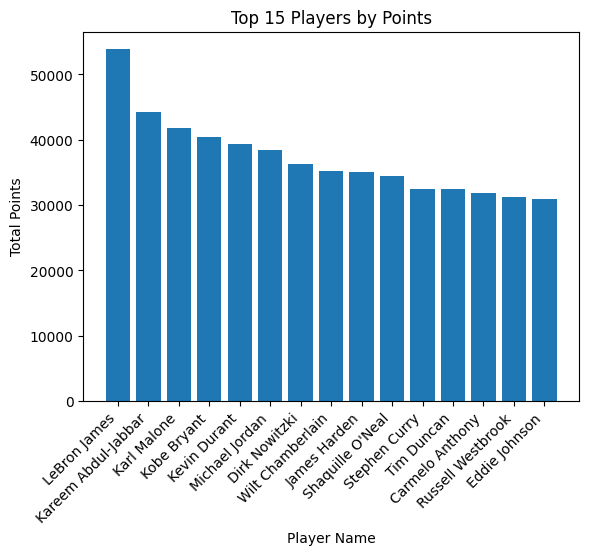

In [28]:
# player_stats

ps = player_stats_cleaned[['firstName','lastName','points']]
ps['fullName'] = ps['firstName'] + ' ' + ps['lastName']

s = ps.groupby(['fullName'])['points'].sum().reset_index()
s = s.sort_values(by='points', ascending=False).head(15)

plt.bar(s['fullName'],s['points'])
plt.xticks(rotation=45, ha='right')

plt.title('Top 15 Players by Points')
plt.xlabel('Player Name')
plt.ylabel('Total Points')
plt.show()

In [29]:
games_cleaned.to_csv('games_cleaned.csv', index=False)
player_stats_cleaned.to_csv('player_stats_cleaned.csv', index=False)
team_histories_cleaned.to_csv('team_histories_cleaned.csv', index=False)
betting_stats_cleaned.to_csv('betting_stats_cleaned.csv', index=False)  